## Load Forecast vs. rtm price correlation

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_DATA_ROOT = Path('../..').resolve() / "01_data"
LOAD_FORECAST = PROJECT_DATA_ROOT / "2_cleaned" / "load" / "forecast" / "Hourly ERCOT system load and prediction 20220201 20251201.csv"
RTM_PRICE = PROJECT_DATA_ROOT / "2_cleaned" / "rtm_price" / "rtm_price_aggregated_2021_2025.csv"
OUT_DIR = PROJECT_DATA_ROOT / "3_analysis" / "load_forecast"
OUT_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
df_rtm = pd.read_csv(RTM_PRICE)
df_load = pd.read_csv(LOAD_FORECAST)
df_load.rename(columns={'actual_ERCOT': 'actual_load', 'error_ERCOT': 'load_forecast_error'}, inplace=True)
df_rtm

,date_time,avg_rtm_price,std_rtm_price
0,2021-01-01 01:00:00,18.714000,1.508854
1,2021-01-01 02:00:00,18.107333,1.512517
2,2021-01-01 03:00:00,17.570000,1.537424
3,2021-01-01 04:00:00,17.670667,1.540869
4,2021-01-01 05:00:00,17.792000,1.997417
...,...,...,...
43310,2025-12-27 20:00:00,17.682000,4.066851
43311,2025-12-27 21:00:00,15.002667,4.357721
43312,2025-12-27 22:00:00,13.227333,4.750020
43313,2025-12-27 23:00:00,14.328667,5.222993


In [3]:
# merge
df_load['datetime'] = pd.to_datetime(df_load['datetime'])
df_rtm['date_time'] = pd.to_datetime(df_rtm['date_time'])
df = df_rtm.merge(df_load, left_on='date_time', right_on='datetime', how='inner')
df = df.drop(columns=['date_time', 'std_rtm_price'])
df

,avg_rtm_price,datetime,actual_load,load_forecast_error
0,13.662000,2022-02-01 01:00:00,35709.832031,-561.832031
1,12.867333,2022-02-01 02:00:00,34733.136719,-679.136719
2,14.420667,2022-02-01 03:00:00,34448.484375,-946.484375
3,18.360667,2022-02-01 04:00:00,34471.617188,-837.617188
4,21.484667,2022-02-01 05:00:00,35127.335938,-571.335938
...,...,...,...,...
33406,73.665333,2025-11-30 20:00:00,55294.851563,-1311.851563
33407,72.008000,2025-11-30 21:00:00,54523.589844,-36.589844
33408,74.346667,2025-11-30 22:00:00,53437.218750,1104.781250
33409,74.175333,2025-11-30 23:00:00,51638.382813,2117.617187


In [4]:
# error in absolute value
df['abs_load_error'] = abs(df['load_forecast_error'])
df

,avg_rtm_price,datetime,actual_load,load_forecast_error,abs_load_error
0,13.662000,2022-02-01 01:00:00,35709.832031,-561.832031,561.832031
1,12.867333,2022-02-01 02:00:00,34733.136719,-679.136719,679.136719
2,14.420667,2022-02-01 03:00:00,34448.484375,-946.484375,946.484375
3,18.360667,2022-02-01 04:00:00,34471.617188,-837.617188,837.617188
4,21.484667,2022-02-01 05:00:00,35127.335938,-571.335938,571.335938
...,...,...,...,...,...
33406,73.665333,2025-11-30 20:00:00,55294.851563,-1311.851563,1311.851563
33407,72.008000,2025-11-30 21:00:00,54523.589844,-36.589844,36.589844
33408,74.346667,2025-11-30 22:00:00,53437.218750,1104.781250,1104.781250
33409,74.175333,2025-11-30 23:00:00,51638.382813,2117.617187,2117.617187


/Users/zyliazhang/Git/ERCOT-Research/.venv/lib/python3.14/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


Text(0.5, 0, 'Load Prediction Error')

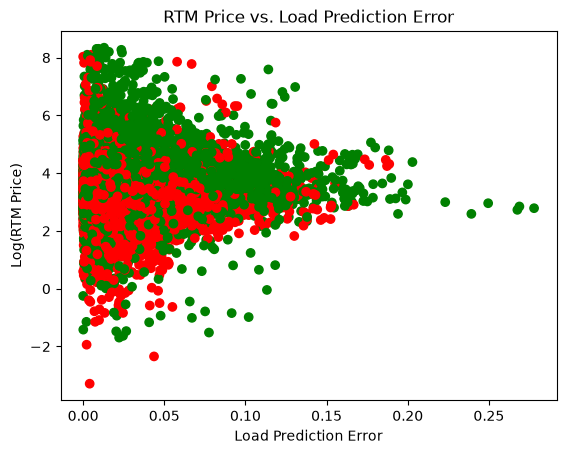

In [5]:
# investigate negative + positive predictions
# error = predicted - actual 

colors = np.where(df['load_forecast_error'] >= 0, 'green', 'red')

plt.scatter(df["abs_load_error"]/df['actual_load'], np.log(df["avg_rtm_price"]), c=colors)
plt.title('RTM Price vs. Load Prediction Error')
plt.ylabel('Log(RTM Price)')
plt.xlabel('Load Prediction Error')

Text(0.5, 0, 'Load')

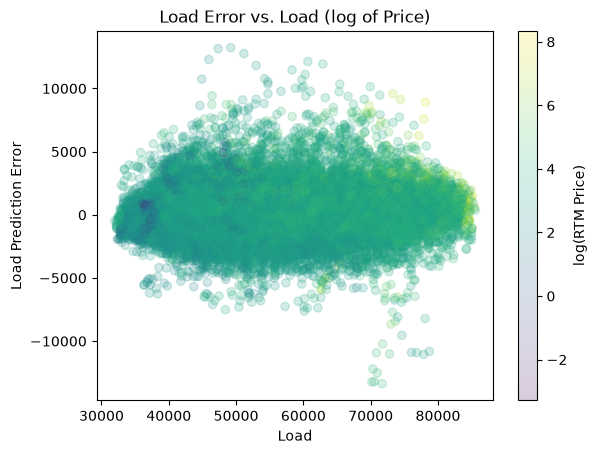

In [6]:
# error vs. load (color log price)

sc = plt.scatter(df['actual_load'], df['load_forecast_error'], alpha=0.2, c=np.log(df['avg_rtm_price']))
plt.colorbar(sc, label='log(RTM Price)')
plt.title('Load Error vs. Load (log of Price)')
plt.ylabel('Load Prediction Error')
plt.xlabel('Load')

In [7]:
df.describe()

,avg_rtm_price,datetime,actual_load,load_forecast_error,abs_load_error
count,33411.000000,33411,33357.000000,33357.000000,33357.000000
mean,46.912971,2024-01-01 08:23:38.514860,52624.958524,91.928064,1261.678999
min,-2.656667,2022-02-01 01:00:00,31955.060547,-13370.523438,0.089844
25%,18.833000,2023-01-20 02:30:00,44189.558594,-928.363281,446.757812
50%,27.455333,2024-01-01 23:00:00,49976.261719,-16.523438,949.851563
75%,45.033333,2024-12-14 22:30:00,59471.500000,974.460937,1697.605469
max,4203.718000,2025-12-01 00:00:00,85558.984375,13228.574219,13370.523438
std,126.764806,NaN,11202.112381,1734.900783,1194.340876


Text(0.5, 0, 'Load')

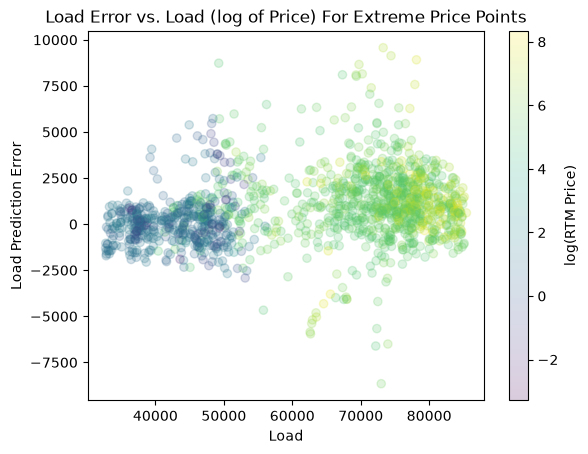

In [8]:
# filter to extreme prices
# error vs. load (color log price)

df_filter = df[(df['avg_rtm_price'] < 5) | (df['avg_rtm_price'] > 150)]

colors = np.sign(df_filter['avg_rtm_price']) * np.log(abs(df_filter['avg_rtm_price']))
sc = plt.scatter(df_filter['actual_load'], df_filter['load_forecast_error'], alpha=0.2, c=colors)
plt.colorbar(sc, label='log(RTM Price)')
plt.title('Load Error vs. Load (log of Price) For Extreme Price Points')
plt.ylabel('Load Prediction Error')
plt.xlabel('Load')

In [ ]:
df_filter.filter([])
df_filter.to_csv(OUT_DIR / 'Mean Extreme Prices', index=False)
df_filter

,avg_rtm_price,datetime,actual_load,load_forecast_error,abs_load_error
78,437.303333,2022-02-04 07:00:00,66128.429688,5652.570312,5652.570312
79,399.934000,2022-02-04 08:00:00,67734.554688,5776.445312,5776.445312
80,245.551333,2022-02-04 09:00:00,68596.421875,3677.578125,3677.578125
359,4.998000,2022-02-16 00:00:00,36229.617188,1013.382812,1013.382812
360,4.062000,2022-02-16 01:00:00,34511.812500,1025.187500,1025.187500
...,...,...,...,...,...
32945,0.230667,2025-11-11 15:00:00,50376.531250,1337.468750,1337.468750
32946,-1.216000,2025-11-11 16:00:00,50062.992188,1709.007812,1709.007812
33350,3.604667,2025-11-28 12:00:00,50527.269531,-1247.269531,1247.269531
33351,1.350000,2025-11-28 13:00:00,49545.726563,-933.726563,933.726563


Text(0.5, 0.98, 'Load Forecast Error vs. Actual Load Over Year (Log of Price)')

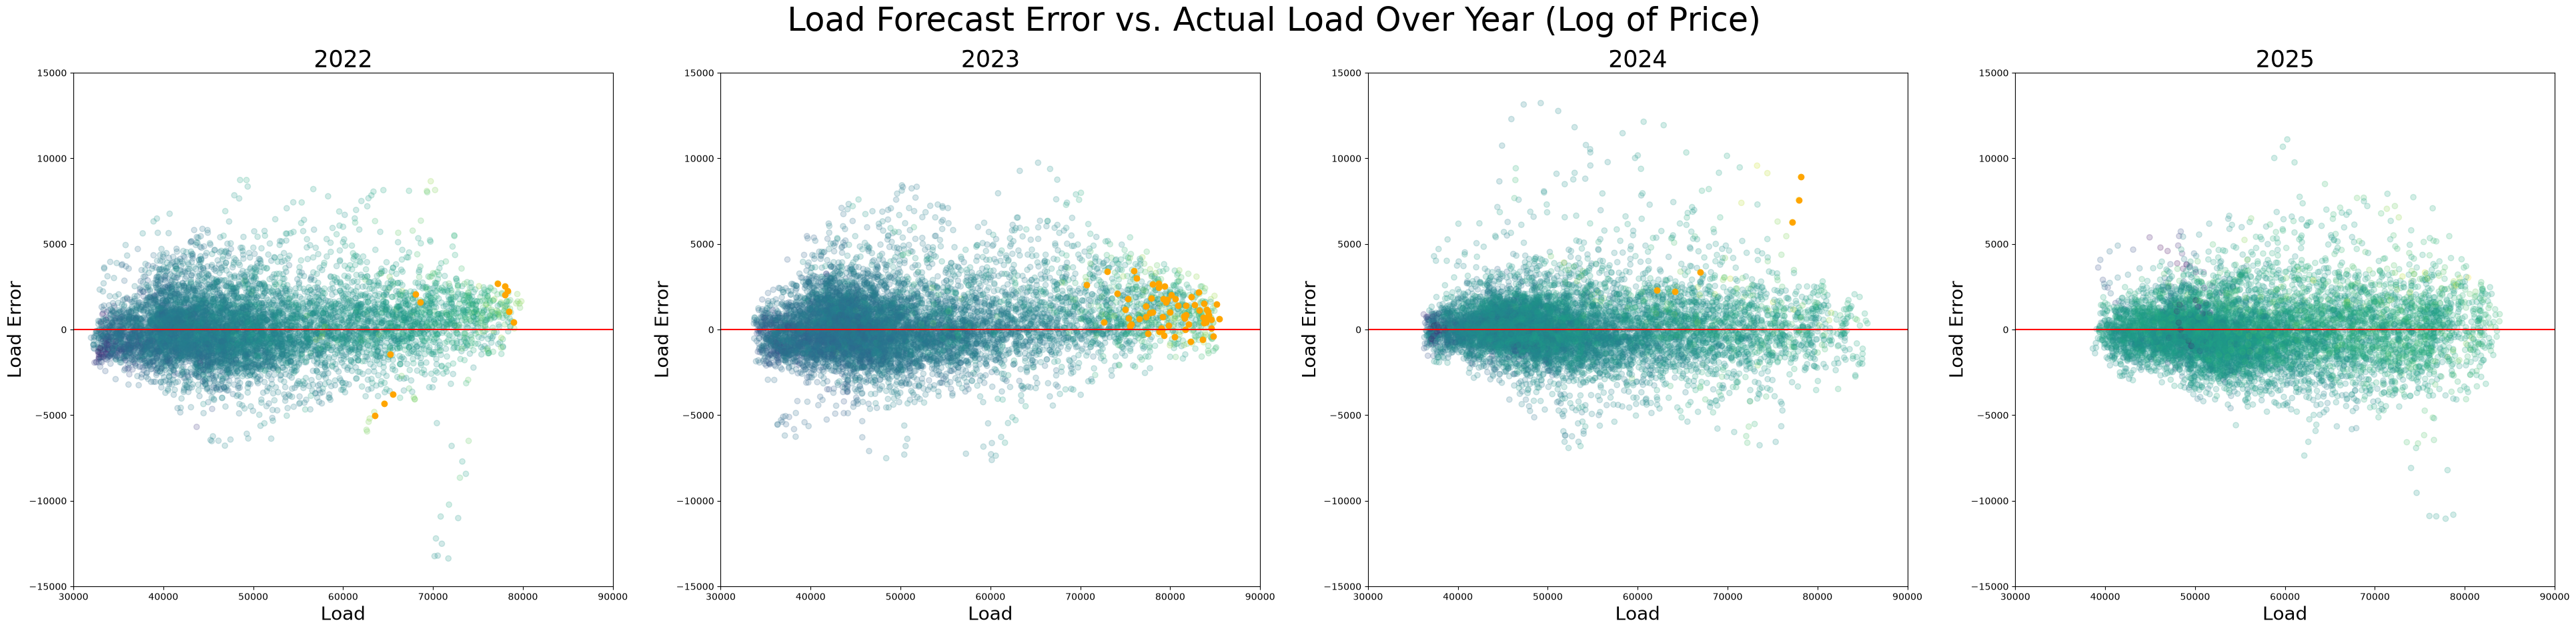

In [15]:
years = [2022, 2023, 2024, 2025]

fig, axes = plt.subplots(1, 4, figsize=(48, 10))
axes = axes.flatten()

for ax, year in zip(axes, years):
    year_data = df[df.index.year == year]
    color_vals = np.sign(year_data['avg_rtm_price']) * np.log1p(np.abs(year_data['avg_rtm_price']))
    ax.scatter(year_data['actual_load'], year_data['load_forecast_error'], alpha=0.2, c=color_vals)
    
    # highlight extreme values
    high_prices = year_data[color_vals > 7]
    ax.scatter(high_prices['actual_load'], high_prices['load_forecast_error'], c='orange')
    ax.hlines(0, 30000, 90000, colors='red')
    ax.set_title(year, fontsize=25)
    ax.set_ylim(-15000, 15000)
    ax.set_xlim(30000, 90000)
    ax.set_ylabel('Load Error', fontsize=20)
    ax.set_xlabel('Load', fontsize=20)

fig.suptitle('Load Forecast Error vs. Actual Load Over Year (Log of Price)', fontsize=35)